ResNet-Transformer for Human Activity Recognition
Device: cpu
Data directory: /content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR
Epochs: 50
Batch size: 64
Learning rate: 0.001
Validation split: 0.2

[1/2] Training Phase
----------------------------------------------------------------------
Loading UCI HAR dataset...
Dataset split:
  Train: 5881 samples
  Val:   1471 samples
  Test:  2947 samples
Using device: cpu


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



Starting training...
Epoch  Train Loss   Train Acc    Val Acc      Status              
----------------------------------------------------------------------
1      0.4184       0.8395       0.9490       ✓ Best model saved! 
2      0.1605       0.9415       0.9558       ✓ Best model saved! 
3      0.1763       0.9384       0.9375                           
4      0.1255       0.9498       0.9599       ✓ Best model saved! 
5      0.1132       0.9526       0.9558                           
6      0.1247       0.9495       0.9579                           
7      0.1111       0.9526       0.9606       ✓ Best model saved! 
8      0.1219       0.9490       0.9565                           
9      0.1075       0.9543       0.9680       ✓ Best model saved! 
10     0.0987       0.9566       0.9483                           
11     0.1094       0.9520       0.9524                           
12     0.0995       0.9553       0.9667                           
13     0.1088       0.9534       0.9

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(



📋 Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.9979    0.9617    0.9795       496
  WALKING_UPSTAIRS     0.9530    0.9469    0.9499       471
WALKING_DOWNSTAIRS     0.9470    0.9786    0.9625       420
           SITTING     0.8962    0.7739    0.8306       491
          STANDING     0.8168    0.9305    0.8699       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9318      2947
         macro avg     0.9352    0.9319    0.9321      2947
      weighted avg     0.9342    0.9318    0.9315      2947

✓ Classification report saved to 'classification_report.csv'
✓ Confusion matrix saved to 'confusion_matrix.png'


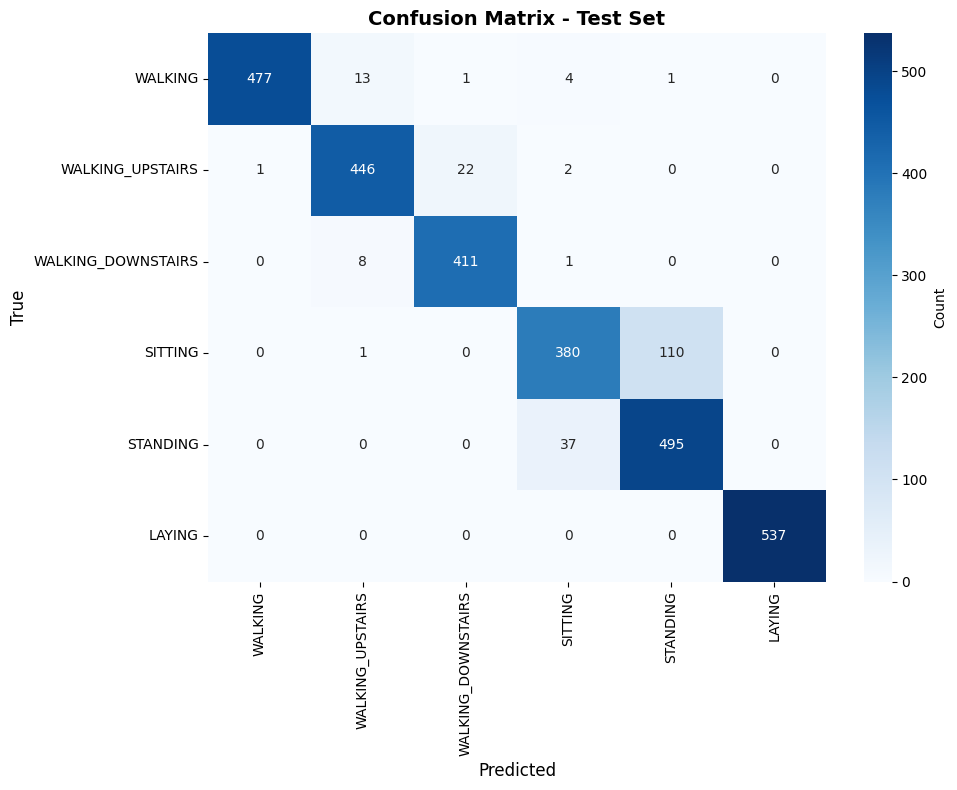

In [5]:
import torch
import torch.nn as nn
import math
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=128):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)  # (T, 1, d_model)

        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: (T, B, d_model)
        """
        return x + self.pe[:x.size(0)]


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.downsample = (
            nn.Sequential(nn.Conv1d(in_channels, out_channels, 1, stride=stride), nn.BatchNorm1d(out_channels))
            if in_channels != out_channels or stride != 1 else nn.Identity()
        )

    def forward(self, x):
        identity = self.downsample(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class ResNetTransformer(nn.Module):
    """
    Input shape: (B, 9, 128)
    [body_acc_x, body_acc_y, body_acc_z,
     body_gyro_x, body_gyro_y, body_gyro_z,
     total_acc_x, total_acc_y, total_acc_z]
    """
    def __init__(self, num_classes, input_channels=9, seq_len=128, d_model=64, nhead=4, num_layers=1):
        super().__init__()

        # Stage 1
        self.stage1_resnet = nn.Sequential(
            ResidualBlock(input_channels, 32),
            ResidualBlock(32, 64)
        )
        self.stage1_proj = nn.Linear(seq_len, d_model)
        self.pos_encoder1 = PositionalEncoding(d_model, max_len=64)
        encoder_layer1 = TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.1, batch_first=False)
        self.stage1_transformer = TransformerEncoder(encoder_layer1, num_layers=num_layers)

        # Stage 2
        self.stage2_resnet = nn.Sequential(
            ResidualBlock(64, 64),
            ResidualBlock(64, 64)
        )
        self.stage2_proj = nn.Linear(d_model, d_model)
        self.pos_encoder2 = PositionalEncoding(d_model, max_len=64)
        encoder_layer2 = TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.1, batch_first=False)
        self.stage2_transformer = TransformerEncoder(encoder_layer2, num_layers=num_layers)

        self.fc = nn.Linear(d_model * 64, num_classes)

    def forward(self, x):
        # Stage 1
        x = self.stage1_resnet(x)                   # (B, 64, 128)
        x = self.stage1_proj(x)                     # (B, 64, d_model)
        x = x.permute(1, 0, 2)                      # (64, B, d_model)
        x = self.pos_encoder1(x)                    # Positional Encoding
        x = self.stage1_transformer(x)              # Transformer
        x = x.permute(1, 0, 2)                      # (B, 64, d_model)

        # Stage 2
        x = x.transpose(1, 2)                       # (B, d_model, 64)
        x = self.stage2_resnet(x)                   # (B, 64, 64)
        x = x.transpose(1, 2)                       # (B, 64, 64)
        x = self.stage2_proj(x)                     # (B, 64, d_model)
        x = x.permute(1, 0, 2)                      # (64, B, d_model)
        x = self.pos_encoder2(x)                    # Positional Encoding
        x = self.stage2_transformer(x)              # Transformer
        x = x.permute(1, 0, 2)                      # (B, 64, d_model)

        x = x.flatten(start_dim=1)                  # (B, 64*d_model)
        return self.fc(x)


class UCIHAR_Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


def load_uci_har_data(data_dir, val_split=0.2):
    """
    UCI HAR 데이터를 로드하고 train/val/test로 분리

    Args:
        data_dir: 데이터 디렉토리 경로
        val_split: 훈련 데이터에서 검증 데이터로 분리할 비율 (기본값: 0.2)

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test
    """
    INPUT_SIGNAL_TYPES = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_"
    ]

    def load_signals(subset):
        signals_data = []
        for signal in INPUT_SIGNAL_TYPES:
            filepath = os.path.join(data_dir, subset, "Inertial Signals", signal + subset + ".txt")
            signals = np.loadtxt(filepath)
            signals_data.append(signals)
        # (9, samples, 128) -> (samples, 9, 128)
        return np.transpose(np.array(signals_data), (1, 0, 2))

    def load_labels(subset):
        filepath = os.path.join(data_dir, subset, "y_" + subset + ".txt")
        # 레이블을 0-based index로 변환 (1-6 -> 0-5)
        return np.loadtxt(filepath) - 1

    # 원본 train/test 로드
    X_train_full = load_signals("train")
    y_train_full = load_labels("train")
    X_test = load_signals("test")
    y_test = load_labels("test")

    # train을 train/val로 분리
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full,
        test_size=val_split,
        random_state=42,
        stratify=y_train_full  # 클래스 비율 유지
    )

    print(f"Dataset split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val:   {len(X_val)} samples")
    print(f"  Test:  {len(X_test)} samples")

    return X_train, y_train, X_val, y_val, X_test, y_test


def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0.0, 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(dataloader), correct / len(dataloader.dataset)


def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            correct += (outputs.argmax(1) == labels).sum().item()
    return correct / len(dataloader.dataset)


def train_pipeline(args):
    """학습 파이프라인"""
    print("Loading UCI HAR dataset...")
    X_train, y_train, X_val, y_val, X_test, y_test = load_uci_har_data(args.data_dir, args.val_split)

    train_dataset = UCIHAR_Dataset(X_train, y_train)
    val_dataset = UCIHAR_Dataset(X_val, y_val)
    test_dataset = UCIHAR_Dataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=args.batch_size)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size)

    device = torch.device(args.device)
    print(f"Using device: {device}")

    model = ResNetTransformer(num_classes=args.num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

    best_val_acc = 0.0
    print("\nStarting training...")
    print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Status':<20}")
    print("-" * 70)

    for epoch in range(args.epochs):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_acc = evaluate_model(model, val_loader, device)

        status = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            os.makedirs(args.save_dir, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(args.save_dir, "best_model.pth"))
            status = "✓ Best model saved!"

        print(f"{epoch+1:<6} {train_loss:<12.4f} {train_acc:<12.4f} {val_acc:<12.4f} {status:<20}")

    print(f"\nTraining completed! Best validation accuracy: {best_val_acc:.4f}")

    # 최종 테스트 평가
    print("\n" + "="*70)
    print("Final Test Evaluation with Best Model")
    print("="*70)
    model.load_state_dict(torch.load(os.path.join(args.save_dir, "best_model.pth"), map_location=device))
    test_acc = evaluate_model(model, test_loader, device)
    print(f"Test Accuracy: {test_acc:.4f}")

    return best_val_acc, test_acc


def evaluate_pipeline(args, model_path):
    """평가 파이프라인 - 테스트 세트에 대한 상세 분석"""
    print("Loading UCI HAR dataset...")
    X_train, y_train, X_val, y_val, X_test, y_test = load_uci_har_data(args.data_dir, args.val_split)
    test_dataset = UCIHAR_Dataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=args.batch_size)

    device = torch.device(args.device)
    print(f"Using device: {device}")

    model = ResNetTransformer(num_classes=args.num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    print("Evaluating model on test set...")
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(predictions)
            y_true.extend(labels.numpy())

    print("\n" + "="*60)
    print("📋 Classification Report:")
    print("="*60)
    print(classification_report(y_true, y_pred, digits=4, target_names=args.class_labels))

    cm = confusion_matrix(y_true, y_pred)

    # Classification Report를 DataFrame으로 저장
    report = classification_report(y_true, y_pred, target_names=args.class_labels, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv("classification_report.csv")
    print("✓ Classification report saved to 'classification_report.csv'")

    # Confusion Matrix 시각화
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=args.class_labels,
                yticklabels=args.class_labels,
                cbar_kws={'label': 'Count'})
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.title("Confusion Matrix - Test Set", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300)
    print("✓ Confusion matrix saved to 'confusion_matrix.png'")
    plt.show()


class Args:
    """설정 클래스"""
    def __init__(self):
        # 데이터 관련
        self.data_dir = '/content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR'
        self.num_classes = 6
        self.class_labels = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                             'SITTING', 'STANDING', 'LAYING']
        self.val_split = 0.2  # 훈련 데이터의 20%를 검증 세트로 사용

        # 학습 관련
        self.epochs = 50
        self.batch_size = 64
        self.lr = 0.001
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        # 저장 관련
        self.save_dir = './checkpoints'
        self.model_path = './checkpoints/best_model.pth'


def main():
    """메인 실행 함수"""
    args = Args()

    print("="*70)
    print("ResNet-Transformer for Human Activity Recognition")
    print("="*70)
    print(f"Device: {args.device}")
    print(f"Data directory: {args.data_dir}")
    print(f"Epochs: {args.epochs}")
    print(f"Batch size: {args.batch_size}")
    print(f"Learning rate: {args.lr}")
    print(f"Validation split: {args.val_split}")
    print("="*70)

    # 학습 실행
    print("\n[1/2] Training Phase")
    print("-"*70)
    best_val_acc, test_acc = train_pipeline(args)

    # 상세 평가 실행
    print("\n[2/2] Detailed Evaluation Phase")
    print("-"*70)
    if os.path.exists(args.model_path):
        evaluate_pipeline(args, args.model_path)
    else:
        print(f"Warning: Model file not found at {args.model_path}")


if __name__ == "__main__":
    main()